In [1]:
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load model
MODEL_PATH = "models/lgbm_model.pkl"  # [PLACEHOLDER: update path]
model = joblib.load(MODEL_PATH)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('best_lgbm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [3]:
df = pd.read_csv("../datasets/cleaned_data.csv")

In [4]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()

In [5]:
print(numeric_cols)
print(categorical_cols)

['year', 'age', 'weight', 'height', 'bmi', 'education', 'income', 'gen_health', 'physical_health_days', 'mental_health_days', 'l_checkup']
['age_group', 'sex', 'race', 'marital_status', 'education_level', 'employment_status', 'income_level', 'general_health', 'exercise', 'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 'had_stroke', 'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier', 'last_checkup', 'has_personal_doctor', 'diabetes']


In [8]:
cat_values = {col: [str(v) for v in df[col].unique()] for col in categorical_cols}

cat_values

{'age_group': ['40 - 44',
  '60 - 64',
  '45 - 49',
  '65 - 69',
  '55 - 59',
  '18 - 24',
  '50 - 54',
  '80+',
  '75 - 79',
  '25 - 29',
  '35 - 39',
  '70 - 74',
  '30 - 34'],
 'sex': ['Female', 'Male'],
 'race': ['White',
  'Black',
  'Asian',
  'Hispanic',
  'American Indian or Alaskan Native',
  'Multiracial',
  'Native Hawaiian or other Pacific Islander',
  'Other'],
 'marital_status': ['Never married',
  'Divorced',
  'Married',
  'Widowed',
  'A member of an unmarried couple',
  'Separated'],
 'education_level': ['Some college (1-3 years) or Technical school',
  'High school graduate (12 or GED)',
  'College graduate (4+ years)',
  'Some high school (9-11)',
  'Elementary (1-8)',
  'None or KG'],
 'employment_status': ['A homemaker',
  'Unable to work',
  'Employed for wages',
  'Retired',
  'Self-employed',
  'A student',
  'Out of work for more than 1 year',
  'Out of work for less that 1 year'],
 'income_level': ['<$10,000',
  '$75,000 - <$100,000',
  '$15,000 - <$20,000',


In [75]:
df.tail(10)

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,...,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
869309,2023,75 - 79,12.0,Female,White,158.0,65.0,26.29,Married,Some college (1-3 years) or Technical school,...,False,No,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
869310,2023,60 - 64,9.0,Male,Hispanic,170.0,69.0,25.10,Married,High school graduate (12 or GED),...,True,No,False,False,False,False,<1 year,1.0,More than one,Non-diabetic
869311,2023,18 - 24,1.0,Male,White,170.0,75.0,21.25,Never married,Some college (1-3 years) or Technical school,...,True,No,False,False,False,True,<1 year,1.0,No,Non-diabetic
869312,2023,70 - 74,11.0,Male,White,185.0,73.0,24.41,Married,Some college (1-3 years) or Technical school,...,True,No,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
869313,2023,60 - 64,9.0,Female,White,143.0,63.0,25.33,Married,College graduate (4+ years),...,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
869314,2023,40 - 44,5.0,Male,Black,220.0,75.0,27.50,Never married,College graduate (4+ years),...,False,No,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
869315,2023,60 - 64,9.0,Male,Black,350.0,77.0,41.50,Married,College graduate (4+ years),...,False,Yes,True,False,True,False,<1 year,1.0,More than one,Diabetic
869316,2023,65 - 69,10.0,Male,White,270.0,70.0,38.74,A member of an unmarried couple,College graduate (4+ years),...,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
869317,2023,45 - 49,6.0,Female,White,190.0,67.0,29.75,Widowed,College graduate (4+ years),...,True,Yes,False,False,False,False,<1 year,1.0,More than one,Non-diabetic
869318,2023,80+,13.0,Male,White,185.0,72.0,25.09,Widowed,High school graduate (12 or GED),...,False,Yes,True,True,True,False,<1 year,1.0,"Yes, only one",Non-diabetic


In [16]:
df.age_group.unique()

<ArrowStringArray>
['40 - 44', '60 - 64', '45 - 49', '65 - 69', '55 - 59', '18 - 24', '50 - 54',
     '80+', '75 - 79', '25 - 29', '35 - 39', '70 - 74', '30 - 34']
Length: 13, dtype: str

In [14]:
df.age.unique()

array([ 5.,  9.,  6., 10.,  8.,  1.,  7., 13., 12.,  2.,  4., 11.,  3.])

In [79]:
def map_age(age):
    if age < 18:
        return 0
    elif age <= 24:
        return 1
    elif age >= 80:
        return 13
    return (age // 5) - 3

map_age(77)

12

In [22]:
df.education_level.unique()

<ArrowStringArray>
['Some college (1-3 years) or Technical school',
             'High school graduate (12 or GED)',
                  'College graduate (4+ years)',
                      'Some high school (9-11)',
                             'Elementary (1-8)',
                                   'None or KG']
Length: 6, dtype: str

In [23]:
df.education.unique()

array([5., 4., 6., 3., 2., 1.])

In [24]:
def map_education(education_level):
    education_map = {
    'None or KG': 1,
    'Elementary (1-8)': 2,
    'Some high school (9-11)': 3,
    'High school graduate (12 or GED)': 4,
    'Some college (1-3 years) or Technical school': 5,
    'College graduate (4+ years)' : 6
    }

    return education_map.get(education_level, 0)  # Return 0 if not found

map_education('Some college (1-3 years) or Technical school')

5

In [10]:
final_df = pd.read_csv("../datasets/final_model_data.csv")
final_df.head(2)

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,...,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes,socioeconomic_tier
0,5.0,Female,35.51,Single,5.0,Student/Homemaker,1.0,4.0,0.0,30.0,...,0,Yes,0,0,0,0,1.0,1,0,1
1,9.0,Male,24.21,Previously Married,5.0,Unable to work,1.0,2.0,3.0,12.0,...,0,Yes,0,0,0,0,1.0,0,0,1


In [40]:
final_df.income.value_counts()

income
8.0     188378
7.0     147480
6.0     119197
5.0      95001
9.0      87955
4.0      55276
11.0     40652
3.0      40205
10.0     39005
2.0      29140
1.0      27030
Name: count, dtype: int64

In [21]:
print(df.columns)
print(final_df.columns)

Index(['year', 'age_group', 'age', 'sex', 'race', 'weight', 'height', 'bmi',
       'marital_status', 'education_level', 'education', 'employment_status',
       'income_level', 'income', 'general_health', 'gen_health',
       'physical_health_days', 'mental_health_days', 'exercise',
       'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 'had_stroke',
       'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier',
       'last_checkup', 'l_checkup', 'has_personal_doctor', 'diabetes'],
      dtype='str')
Index(['age', 'sex', 'bmi', 'marital_status', 'education', 'employment_status',
       'income', 'gen_health', 'physical_health_days', 'mental_health_days',
       'exercise', 'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp',
       'had_stroke', 'had_heart_attack', 'had_coronary_heart_disease',
       'cost_barrier', 'l_checkup', 'has_personal_doctor', 'diabetes',
       'socioeconomic_tier'],
      dtype='str')


In [70]:
# ── 3. Sample input
# Represents a single patient's data as it would arrive from the app form.
sample_input = {
    # Numeric
    'age'                       : map_age(52), # age in years (will be scaled)
    'height'                    : 175,         # height in cm
    'weight'                    : 80,          # weight in kg
    'education'                 : map_education('None or KG'),# ordinal encoded level
    'income'                    : 8,           # [PLACEHOLDER: income in figures]
    'gen_health'                : 4,           # ordinal: 1 (poor) to 5 (excellent)
    'physical_health_days'      : 5,
    'mental_health_days'        : 3,
    'smoked_100_cigarettes'     : 1,           # binary: 0/1
    'drinks_alcohol'            : 1,           # binary: 0/1
    'had_coronary_heart_disease': 0,           # binary: 0/1
    'cost_barrier'              : 0,           # binary: 0/1
    'l_checkup'                 : 1,           # [PLACEHOLDER: confirm encoding — recency ordinal?]
    'had_stroke'                : 0,           # binary: 0/1
    'had_heart_attack'          : 0,           # binary: 0/1
    'has_personal_doctor'       : 1,           # binary: 0/1

    # Categorical
    'sex'              : 'Male',               # 'Male' / 'Female'
    'marital_status'   : 'Married/Cohabiting', # 'Married/Cohabiting' / 'Previously Married' / 'Single'
    'employment_status': 'Employed',           # 'Employed' / 'Retired' / 'Unemployed' / 'Not in workforce' / 'Student' / 'Unable to work'
    'exercise'         : 'False',              # [PLACEHOLDER: confirm — 'Yes'/'No' or True/False?]
    'high_bp'          : 'No',                 # 'Yes' / 'No' / 'Borderline'
    'socioeconomic_tier': 1                    # 1/2/3
}

In [71]:
# ── 4. Convert to DataFrame
input_df = pd.DataFrame([sample_input])
input_df['bmi'] = input_df['weight'] / ((input_df['height'] / 100) ** 2)  # BMI calculation
input_df = input_df.drop(columns=['height', 'weight'])  # Drop height and weight after BMI calculation
print(input_df.info())
input_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1 non-null      int64  
 1   education                   1 non-null      int64  
 2   income                      1 non-null      int64  
 3   gen_health                  1 non-null      int64  
 4   physical_health_days        1 non-null      int64  
 5   mental_health_days          1 non-null      int64  
 6   smoked_100_cigarettes       1 non-null      int64  
 7   drinks_alcohol              1 non-null      int64  
 8   had_coronary_heart_disease  1 non-null      int64  
 9   cost_barrier                1 non-null      int64  
 10  l_checkup                   1 non-null      int64  
 11  had_stroke                  1 non-null      int64  
 12  had_heart_attack            1 non-null      int64  
 13  has_personal_doctor         1 non-null      int64 

,age,education,income,gen_health,physical_health_days,mental_health_days,smoked_100_cigarettes,drinks_alcohol,had_coronary_heart_disease,cost_barrier,...,had_stroke,had_heart_attack,has_personal_doctor,sex,marital_status,employment_status,exercise,high_bp,socioeconomic_tier,bmi
0,6,1,8,4,5,3,1,1,0,0,...,0,0,1,Male,Married/Cohabiting,Employed,False,No,1,26.122449


In [68]:
prediction = model.predict(input_df)
proba = model.predict_proba(input_df)

prob_non_diabetic = proba[0][0]
prob_diabetic     = proba[0][1]
predicted_class   = "Diabetic" if prediction[0] == 1 else "Non-diabetic"

print("\n─── Prediction Results ───────────────────────────────")
print(f"Predicted class        : {predicted_class}")
print(f"Probability (diabetic) : {prob_diabetic:.4f}  ({prob_diabetic*100:.1f}%)")
print(f"Probability (non-diab) : {prob_non_diabetic:.4f}  ({prob_non_diabetic*100:.1f}%)")


─── Prediction Results ───────────────────────────────
Predicted class        : Non-diabetic
Probability (diabetic) : 0.3403  (34.0%)
Probability (non-diab) : 0.6597  (66.0%)


/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [49]:
explainer = joblib.load("models/shap_explainer.pkl")
explainer

In [62]:
def clean_feature_name(name):
    # 1. Remove sklearn prefixes
    clean = name.replace('num__', '').replace('cat__', '')
    
    # 2. Specific clinical and professional manual renames
    mapping = {
        'age': 'Age',
        'bmi': 'Body Mass Index (BMI)',
        'education': 'Education Level',
        'income': 'Income Level',
        'gen_health': 'General Health Self-Rating',
        'physical_health_days': 'Physical Health (Recent Bad Days)',
        'mental_health_days': 'Mental Health (Recent Bad Days)',
        'smoked_100_cigarettes': 'Smoked >= 100 Cigarettes Lifetime',
        'drinks_alcohol': 'Alcohol Consumption',
        'had_stroke': 'History of Stroke',
        'had_heart_attack': 'History of Heart Attack',
        'had_coronary_heart_disease': 'History of Coronary Heart Disease',
        'cost_barrier': 'Healthcare Cost Barrier',
        'l_checkup': 'Time Since Last Medical Checkup',
        'has_personal_doctor': 'Has Personal Healthcare Provider',
        'socioeconomic_tier': 'Socioeconomic Tier',
        
        # Categorical break-outs
        'sex_Female': 'Sex: Female',
        'sex_Male': 'Sex: Male',
        'marital_status_Married/Cohabiting': 'Marital Status: Married/Cohabiting',
        'marital_status_Previously Married': 'Marital Status: Previously Married',
        'marital_status_Single': 'Marital Status: Single',
        'employment_status_Employed': 'Employment: Employed',
        'employment_status_Retired': 'Employment: Retired',
        'employment_status_Student/Homemaker': 'Employment: Student/Homemaker',
        'employment_status_Unable to work': 'Employment: Unable to Work',
        'employment_status_Unemployed': 'Employment: Unemployed',
        'exercise_False': 'Physical Exercise: No',
        'exercise_True': 'Physical Exercise: Yes',
        'high_bp_Borderline': 'Blood Pressure: Borderline High',
        'high_bp_No': 'Blood Pressure: Normal/No',
        'high_bp_Yes': 'Blood Pressure: Hypertension/Yes'
    }
    
    return mapping.get(clean, clean)

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



─── SHAP Values (raw) ────────────────────────────────
Base value (expected output): -0.7273
SHAP sum + base value       : -1.6548
Model log-odds output       : 0.1605

─── Top 10 SHAP Contributions (this patient) ────────
                         feature  shap_value
      General Health Self-Rating   -0.340225
                 Education Level    0.267270
       Blood Pressure: Normal/No   -0.258188
                             Age   -0.176587
             Alcohol Consumption   -0.173784
Blood Pressure: Hypertension/Yes   -0.169544
 Time Since Last Medical Checkup    0.167272
           Body Mass Index (BMI)   -0.154293
                     Sex: Female    0.138812
                    Income Level   -0.127845


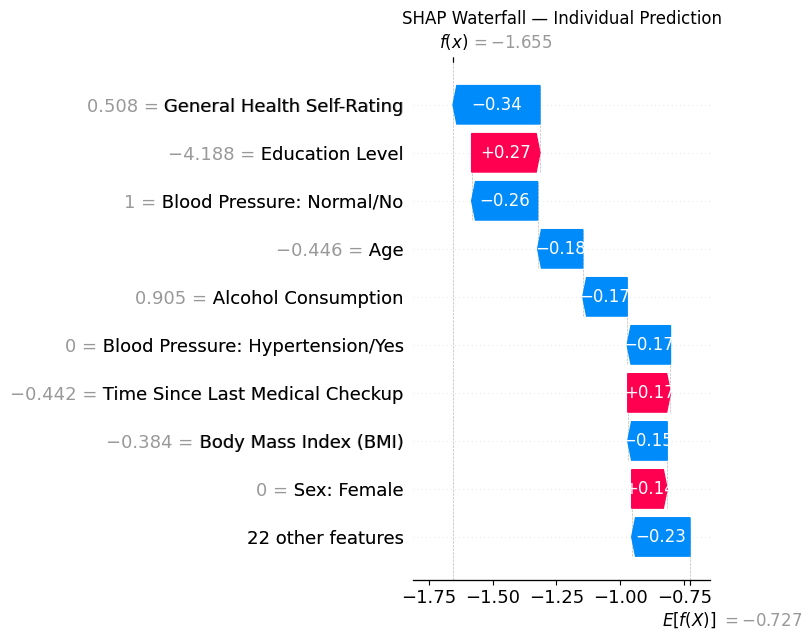


Waterfall plot saved to shap_waterfall_sample.png

─── Result Dictionary (app-ready structure) ──────────
  predicted_class: Non-diabetic
  risk_probability: 0.3403
  top_risk_factors: [{'feature': 'General Health Self-Rating', 'shap_value': -0.3402249231778643}, {'feature': 'Education Level', 'shap_value': 0.2672704968308791}, {'feature': 'Blood Pressure: Normal/No', 'shap_value': -0.25818796692023965}, {'feature': 'Age', 'shap_value': -0.17658680276250802}, {'feature': 'Alcohol Consumption', 'shap_value': -0.17378418019348837}]
  base_value: -0.7273


In [72]:
# ── 7. SHAP values
preprocessor = model.named_steps['preprocessor']
input_processed = preprocessor.transform(input_df)
shap_values = explainer.shap_values(input_processed)

# For binary classification, shap_values is a list of two arrays [class_0, class_1]
# We want class 1 (diabetic)
if isinstance(shap_values, list):
    sv = shap_values[1]   # SHAP values for diabetic class
else:
    sv = shap_values      # some LGBM versions return a single array for binary

print("\n─── SHAP Values (raw) ────────────────────────────────")
print(f"Base value (expected output): {explainer.expected_value:.4f}")
print(f"SHAP sum + base value       : {sv[0].sum() + explainer.expected_value:.4f}")
print(f"Model log-odds output       : {model.predict_proba(input_df)[0][1]:.4f}")

# ── 8. Map SHAP values back to feature names
feature_names = preprocessor.get_feature_names_out()
cleaned_feature_names = np.array([clean_feature_name(name) for name in feature_names])

# Build a readable SHAP summary for this individual
shap_df = pd.DataFrame({
    'feature'    : cleaned_feature_names,
    'shap_value' : sv[0],
}).sort_values('shap_value', key=abs, ascending=False)

print("\n─── Top 10 SHAP Contributions (this patient) ────────")
print(shap_df.head(10).to_string(index=False))

# ── 9. SHAP waterfall plot ─────────────────────────────────────────────────────
shap_explanation = shap.Explanation(
    values    = sv[0],
    base_values = explainer.expected_value,
    data      = input_processed[0],
    feature_names = cleaned_feature_names
)

plt.figure()
shap.plots.waterfall(shap_explanation, max_display=10, show=False)
plt.title("SHAP Waterfall — Individual Prediction")
plt.tight_layout()
plt.savefig("shap_waterfall_sample.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nWaterfall plot saved to shap_waterfall_sample.png")

# ── 10. Package results as a dictionary ────────────────────────────────────────
# This is the structure the app will eventually consume
result = {
    'predicted_class'   : predicted_class,
    'risk_probability'  : round(float(prob_diabetic), 4),
    'top_risk_factors'  : shap_df.head(5)[['feature', 'shap_value']].to_dict(orient='records'),
    'base_value'        : round(float(explainer.expected_value), 4),
    'shap_values'       : dict(zip(feature_names, sv[0].tolist())),
}

print("\n─── Result Dictionary (app-ready structure) ──────────")
for k, v in result.items():
    if k not in ('shap_values',):   # skip full dict for readability
        print(f"  {k}: {v}")


In [2]:
df = pd.read_csv("../datasets/final_model_data.csv")
df.head(2)

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,...,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes,socioeconomic_tier
0,5.0,Female,35.51,Single,5.0,Student/Homemaker,1.0,4.0,0.0,30.0,...,0,Yes,0,0,0,0,1.0,1,0,1
1,9.0,Male,24.21,Previously Married,5.0,Unable to work,1.0,2.0,3.0,12.0,...,0,Yes,0,0,0,0,1.0,0,0,1


In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'marital_status', 'education', 'employment_status',
       'income', 'gen_health', 'physical_health_days', 'mental_health_days',
       'exercise', 'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp',
       'had_stroke', 'had_heart_attack', 'had_coronary_heart_disease',
       'cost_barrier', 'l_checkup', 'has_personal_doctor', 'diabetes',
       'socioeconomic_tier'],
      dtype='str')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         869319 non-null  float64
 1   sex                         869319 non-null  str    
 2   bmi                         869319 non-null  float64
 3   marital_status              869319 non-null  str    
 4   education                   869319 non-null  float64
 5   employment_status           869319 non-null  str    
 6   income                      869319 non-null  float64
 7   gen_health                  869319 non-null  float64
 8   physical_health_days        869319 non-null  float64
 9   mental_health_days          869319 non-null  float64
 10  exercise                    869319 non-null  bool   
 11  smoked_100_cigarettes       869319 non-null  int64  
 12  drinks_alcohol              869319 non-null  int64  
 13  high_bp                  

In [9]:
cat_values = {col: [str(val) for val in df[col].unique()] for col in df.columns}
cat_values

{'age': ['5.0',
  '9.0',
  '6.0',
  '10.0',
  '8.0',
  '1.0',
  '7.0',
  '13.0',
  '12.0',
  '2.0',
  '4.0',
  '11.0',
  '3.0'],
 'sex': ['Female', 'Male'],
 'bmi': ['35.51',
  '24.21',
  '27.96',
  '30.68',
  '37.33',
  '29.18',
  '21.3',
  '20.8',
  '36.9',
  '40.74',
  '31.0',
  '24.75',
  '36.58',
  '25.6',
  '34.3',
  '32.98',
  '31.88',
  '27.45',
  '31.01',
  '27.47',
  '27.34',
  '25.68',
  '22.86',
  '28.57',
  '35.87',
  '24.36',
  '23.75',
  '25.77',
  '29.53',
  '39.48',
  '29.05',
  '22.38',
  '25.1',
  '27.11',
  '25.54',
  '21.45',
  '28.79',
  '23.17',
  '27.39',
  '31.95',
  '20.67',
  '26.69',
  '28.19',
  '36.61',
  '58.52',
  '27.98',
  '27.46',
  '20.09',
  '21.52',
  '28.12',
  '42.96',
  '24.23',
  '29.83',
  '33.96',
  '28.48',
  '31.87',
  '28.06',
  '27.77',
  '39.75',
  '17.94',
  '27.07',
  '34.43',
  '21.63',
  '41.96',
  '29.52',
  '25.06',
  '30.66',
  '29.26',
  '22.65',
  '36.35',
  '25.85',
  '22.62',
  '27.87',
  '38.74',
  '24.27',
  '20.79',
  '37.2

In [11]:
df_old = pd.read_csv("../datasets/cleaned_data.csv")
cat_values_old = {col: [str(val) for val in df_old[col].unique()] for col in df_old.select_dtypes(exclude='number').columns.tolist()}
cat_values_old


{'age_group': ['40 - 44',
  '60 - 64',
  '45 - 49',
  '65 - 69',
  '55 - 59',
  '18 - 24',
  '50 - 54',
  '80+',
  '75 - 79',
  '25 - 29',
  '35 - 39',
  '70 - 74',
  '30 - 34'],
 'sex': ['Female', 'Male'],
 'race': ['White',
  'Black',
  'Asian',
  'Hispanic',
  'American Indian or Alaskan Native',
  'Multiracial',
  'Native Hawaiian or other Pacific Islander',
  'Other'],
 'marital_status': ['Never married',
  'Divorced',
  'Married',
  'Widowed',
  'A member of an unmarried couple',
  'Separated'],
 'education_level': ['Some college (1-3 years) or Technical school',
  'High school graduate (12 or GED)',
  'College graduate (4+ years)',
  'Some high school (9-11)',
  'Elementary (1-8)',
  'None or KG'],
 'employment_status': ['A homemaker',
  'Unable to work',
  'Employed for wages',
  'Retired',
  'Self-employed',
  'A student',
  'Out of work for more than 1 year',
  'Out of work for less that 1 year'],
 'income_level': ['<$10,000',
  '$75,000 - <$100,000',
  '$15,000 - <$20,000',


In [12]:
import json

In [27]:

with open("../streamlit-deployment/cat-values.json", 'r') as f:
    cat_values = json.load(f)
print(cat_values)

{'age': [], 'sex': ['Female', 'Male'], 'height': [], 'weight': [], 'marital_status': ['Single', 'Previously Married', 'Married/Cohabiting'], 'education': ['None or KG', 'Elementary (1-8)', 'Some high school (9-11)', 'High school graduate (12 or GED)', 'Some college (1-3 years) or Technical school', 'College graduate (4+ years)'], 'employment_status': ['Student/Homemaker', 'Unable to work', 'Employed', 'Retired', 'Unemployed'], 'income': [], 'gen_health': [], 'physical_health_days': [], 'mental_health_days': [], 'exercise': ['False', 'True'], 'smoked_100_cigarettes': ['Yes', 'No'], 'drinks_alcohol': ['Yes', 'No'], 'high_bp': ['Yes', 'No', 'Borderline'], 'had_stroke': ['Yes', 'No'], 'had_heart_attack': ['Yes', 'No'], 'had_coronary_heart_disease': ['Yes', 'No'], 'cost_barrier': ['Yes', 'No'], 'l_checkup': [1, 2, 3, 4, 5], 'has_personal_doctor': ['Yes', 'No'], 'socioeconomic_tier': ['Low (barely afford basic necessities)', 'Middle (comfortably afford basic necessities)', 'High (can afford 